# 4.0 The Perceptron

The perceptron is the building block of neural networks. It computes a weighted sum of its inputs, adds a bias, and passes the result through an activation function. In this notebook we:

1. Build a perceptron from scratch with NumPy.
2. Train it with the classic perceptron learning rule to separate seismic events from noise.
3. Reuse the same perceptron as a linear regressor trained by gradient descent, and compare it to ordinary least squares (OLS).
4. Study how the learning rate changes training.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

import mlgeo_synth

## 1. A perceptron from scratch

A perceptron with inputs $x_1, \dots, x_n$, weights $w_1, \dots, w_n$, and bias weight $b$ computes

$$o = \phi\left(\sum_j w_j x_j + b\right),$$

where $\phi$ is the activation function. We implement three activations: none (identity), sigmoid, and step.

In [2]:
class simplePerceptron:
    # Activation functions
    def __none(x):
        return x
    def __sigmoid(x):
        return 1 / (1 + np.exp(-x))
    def __step(x):
        out = np.zeros(x.shape)
        out[x >= 0] = 1
        return out
    possibleActivations = {
        'none': __none,
        'sigmoid': __sigmoid,
        'step': __step
    }
    # Initialize
    def __init__(self, w=None, b_w=None, activation=None):
        if w is None:
            self.w = 0
        else:
            self.w = w
        if b_w is None:
            self.b_w = 0
        else:
            self.b_w = b_w
        if (activation is None) or (activation not in self.possibleActivations):
            self.activation = 'none'
        else:
            self.activation = activation
    def setWs(self, w, b_w):
        self.w = w
        self.b_w = b_w
    def predict(self, x):
        # x should be an (m, n) array: each row is one observation
        weightedSum = np.zeros(x.shape[0])
        for i in range(len(self.w)):
            weightedSum += self.w[i] * x[:, i]
        summed = weightedSum + (1 * self.b_w)
        return self.possibleActivations[self.activation](summed)

### 1.1 Test the perceptron

With one weight set to 1, bias 0, and no activation, the perceptron should return its input unchanged.

In [3]:
ourPerceptron = simplePerceptron(w=[0], b_w=1, activation='none')
ourPerceptron.setWs([1], 0)
testInput = np.array([[100, -1, 0.1]]).T
ourPerceptron.predict(testInput)

array([100. ,  -1. ,   0.1])

## 2. Classifying seismic detections

Seismic detectors summarize short windows of a seismogram with a few features. The `mlgeo_synth.detector_features` table contains four such features per window: the STA/LTA ratio (`sta_lta`), the kurtosis of the waveform, the spectral centroid in Hz, and the dominant frequency in Hz. The label is 1 for an earthquake window and 0 for a noise window, with balanced classes.

We use two features, `sta_lta` and `spectral_centroid_hz`. Events have impulsive arrivals (high STA/LTA) and more high-frequency energy (high spectral centroid) than background noise.

     sta_lta   kurtosis  spectral_centroid_hz  dominant_freq_hz  label
0  10.419133  22.113184              9.556484          7.786286      1
1   3.314406   2.773164              1.716694          1.009758      0
2   2.336543   4.639630              1.271397          0.251278      0
3   3.976867  13.591792              6.692700          4.682170      1
4   1.151811   3.131239              4.474578          1.426544      0


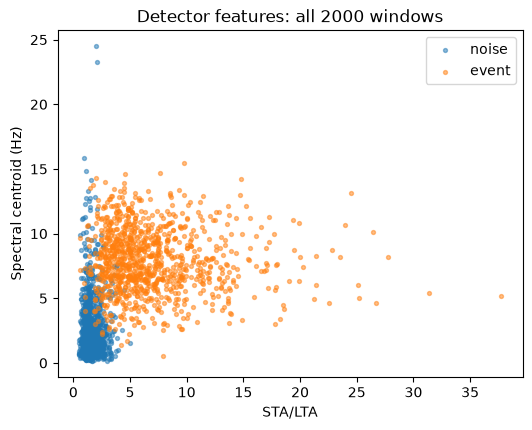

In [4]:
df = mlgeo_synth.detector_features(n=2000, event_fraction=0.5, seed=0)
print(df.head())

fig, ax = plt.subplots(figsize=(6, 4.5))
for lbl, name in [(0, 'noise'), (1, 'event')]:
    part = df[df['label'] == lbl]
    ax.scatter(part['sta_lta'], part['spectral_centroid_hz'], s=8, alpha=0.5, label=name)
ax.set_xlabel('STA/LTA')
ax.set_ylabel('Spectral centroid (Hz)')
ax.set_title('Detector features: all 2000 windows')
ax.legend();

### 2.1 Why an easy two-feature slice?

The classic perceptron learning rule only converges when the data are **linearly separable**: some line must classify every training sample correctly. If the classes overlap, the rule keeps updating forever. The scatter above shows a small overlap band between the two clouds, so the full dataset is not linearly separable.

We therefore select a near-linearly-separable subset: we compute a simple combined score, `sta_lta + spectral_centroid_hz`, and drop the samples in the overlap band. We also stick to exactly two features so we can draw the decision boundary as a line in the plane. Real detector data is messier; later notebooks handle the overlap with multi-layer networks and gradient-based losses.

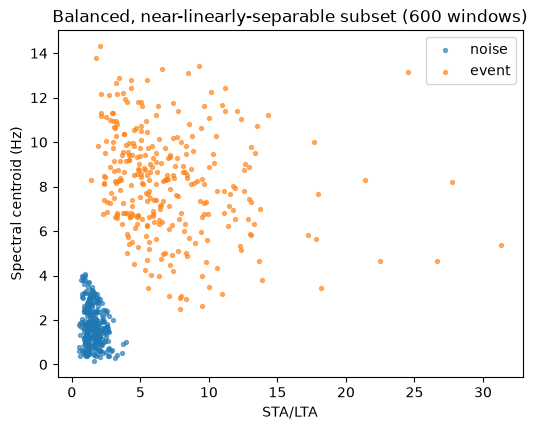

In [5]:
score = df['sta_lta'] + df['spectral_centroid_hz']
keep = ((df['label'] == 0) & (score < 5)) | ((df['label'] == 1) & (score > 9))
subset = df[keep]

# Balance the classes: 300 windows of each
rng = np.random.default_rng(42)
noise_idx = rng.choice(subset.index[subset['label'] == 0], 300, replace=False)
event_idx = rng.choice(subset.index[subset['label'] == 1], 300, replace=False)
subset = subset.loc[np.concatenate([noise_idx, event_idx])]

simpleInputs = subset[['sta_lta', 'spectral_centroid_hz']].to_numpy()
simpleOutputs = subset['label'].to_numpy()

# Shuffle the samples
p = rng.permutation(len(simpleInputs))
simpleInputs = simpleInputs[p, :]
simpleOutputs = simpleOutputs[p]

fig, ax = plt.subplots(figsize=(6, 4.5))
for lbl, name in [(0, 'noise'), (1, 'event')]:
    m = simpleOutputs == lbl
    ax.scatter(simpleInputs[m, 0], simpleInputs[m, 1], s=8, alpha=0.6, label=name)
ax.set_xlabel('STA/LTA')
ax.set_ylabel('Spectral centroid (Hz)')
ax.set_title('Balanced, near-linearly-separable subset (600 windows)')
ax.legend();

### 2.2 The perceptron learning rule

We start with all weights set to 0 and use the step activation, so the perceptron outputs 0 or 1. We then sweep through the dataset. For each sample we:

1. Make a prediction with the current weights.
2. Update each weight with the rule

    $w_j = w_j + \Delta w_j$, where $\Delta w_j = \eta\,(t^i - o^i)\,x^i_j$

    Here $\eta$ is the **learning rate**, $t^i$ and $o^i$ are the target and the output for sample $i$, and $x^i_j$ is input $j$ of that sample. The bias weight gets the same update with input 1. Note that correctly classified samples ($t^i = o^i$) leave the weights unchanged.

3. Repeat full sweeps (epochs) over the data until one epoch produces zero mistakes.

One detail: with zero initial weights, the learning rate only scales the final weight vector. The step activation ignores that scale, so the sequence of predictions, and the number of epochs to converge, is the same for any $\eta > 0$.

In [6]:
percept = simplePerceptron(w=np.zeros(2), b_w=0.0, activation='step')

learningRate = 0.01
maxEpochs = 50
mistakesPerEpoch = []

for epoch in range(maxEpochs):
    mistakes = 0
    for i in range(len(simpleInputs)):
        thisInput = simpleInputs[i:i + 1, :]
        thisTarget = simpleOutputs[i]
        out = percept.predict(thisInput)[0]
        error = thisTarget - out
        if error != 0:
            mistakes += 1
            percept.setWs(percept.w + learningRate * error * thisInput[0],
                          percept.b_w + learningRate * error)
    mistakesPerEpoch.append(mistakes)
    if mistakes == 0:
        break

accuracy = (percept.predict(simpleInputs) == simpleOutputs).mean()
print(f'Converged after {len(mistakesPerEpoch)} epochs; mistakes per epoch: {mistakesPerEpoch}')
print(f'Weights: {percept.w}, bias: {percept.b_w:.3f}, training accuracy: {accuracy:.3f}')

Converged after 2 epochs; mistakes per epoch: [42, 0]
Weights: [0.03415388 0.03796047], bias: -0.220, training accuracy: 1.000


The rule converges in a few epochs and classifies every training sample correctly. Because we use two features, the decision boundary is the line $w_1 x_1 + w_2 x_2 + b = 0$, which we can draw directly.

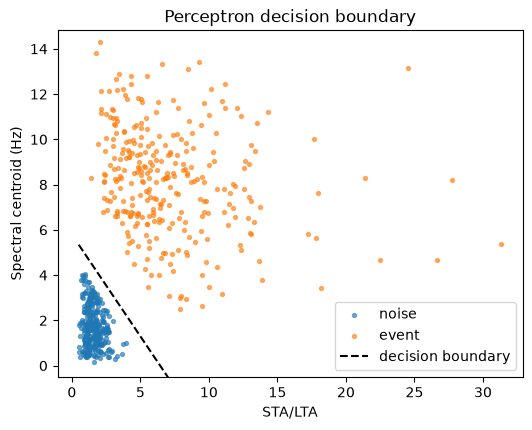

In [7]:
fig, ax = plt.subplots(figsize=(6, 4.5))
for lbl, name in [(0, 'noise'), (1, 'event')]:
    m = simpleOutputs == lbl
    ax.scatter(simpleInputs[m, 0], simpleInputs[m, 1], s=8, alpha=0.6, label=name)

# Decision boundary: w1*x1 + w2*x2 + b = 0  ->  x2 = -(w1*x1 + b) / w2
x1 = np.linspace(simpleInputs[:, 0].min(), simpleInputs[:, 0].max(), 100)
x2 = -(percept.w[0] * x1 + percept.b_w) / percept.w[1]
ax.plot(x1, x2, 'k--', label='decision boundary')

ax.set_xlabel('STA/LTA')
ax.set_ylabel('Spectral centroid (Hz)')
ax.set_ylim(-0.5, simpleInputs[:, 1].max() + 0.5)
ax.set_title('Perceptron decision boundary')
ax.legend();

We just implemented an **online** algorithm: the weights update after every sample, not after seeing the whole dataset.

**Exercise.** Swap `spectral_centroid_hz` for `kurtosis` in the subset-selection cell (keep the same score-based filter on the original features). Does the learning rule still converge within 50 epochs? Why or why not?

```{admonition} Solution
:class: dropdown
It usually does not converge. The score filter removed the overlap in the (STA/LTA, spectral centroid) plane, but the same windows can still overlap in the (STA/LTA, kurtosis) plane. When the classes overlap, no line classifies every sample correctly, so the rule keeps making mistakes every epoch and `mistakesPerEpoch` never reaches zero. To make it converge you would need to re-select a subset that is separable in the new feature pair.
```

## 3. Fitting a line with gradient descent

The same perceptron, with no activation, is a linear model $o = w x + b$. Instead of the perceptron rule, we can train it by **gradient descent** on a cost function. We generate a noisy linear dataset to fit.

In [8]:
num = 100
xRange = [0, 5]
yRange = [0, 2.5]

rng = np.random.default_rng(1)

x = np.linspace(xRange[0], xRange[1], num=num)
y = np.linspace(yRange[0], yRange[1], num=num)

# Add uniform noise in [-0.5, 0.5]
noise_factor = 0.5
x = x + (rng.random(num) * 2 - 1) * noise_factor
y = y + (rng.random(num) * 2 - 1) * noise_factor

# Shuffle x and y together
p = rng.permutation(num)
x = x[p]
y = y[p]

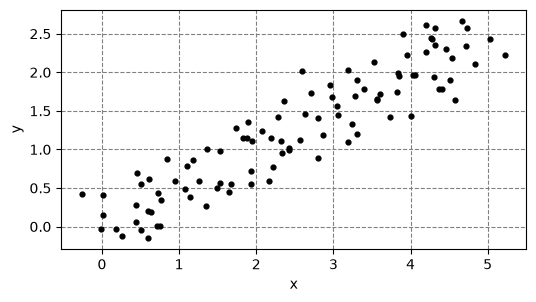

In [9]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(x, y, color='k', s=12)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_aspect('equal')
ax.set_axisbelow(True)
ax.grid(color='gray', linestyle='dashed')

### 3.1 Cost function

We use the mean squared error (MSE) as the cost.

In [10]:
def mseCost(prediction, target):
    mse = (np.square(prediction - target)).mean()
    return mse

# Sanity check: the cost of a perfect prediction is zero
mseCost(y, y)

np.float64(0.0)

### 3.2 Gradient descent

Gradient descent repeats three steps: predict, measure the cost, and move the weights a small step against the cost gradient. For MSE and a linear model the weight update is $\Delta w = \eta\, X^T (t - o)$ and the bias update is $\Delta b = \eta \sum_i (t^i - o^i)$. We stop when the cost change falls below a tolerance, the cost stops being finite (divergence), or we hit the iteration limit.

In [11]:
def gradientDescent(perceptron, costFunction, trainInput, trainTarget,
                    learningRate, numIterations, stoppingCriterion):
    weights = []
    biases = []
    costs = []
    previousCost = None
    for i in range(numIterations):
        # Run the prediction
        prediction = perceptron.predict(trainInput)
        # Determine the cost
        thisCost = costFunction(prediction, trainTarget)
        # Stop if the cost diverged
        if not np.isfinite(thisCost):
            break
        # Stop if the change in cost is below the stopping criterion
        if previousCost and np.absolute(previousCost - thisCost) <= stoppingCriterion:
            break
        previousCost = thisCost
        # Record this weight, bias, and cost
        weights.append(perceptron.w)
        biases.append(perceptron.b_w)
        costs.append(thisCost)
        # Errors
        er = np.subtract(trainTarget, prediction)
        # Weight and bias updates
        weightUpdate = learningRate * np.dot(trainInput.T, er)
        biasWeightUpdate = learningRate * np.sum(er)
        perceptron.setWs(perceptron.w + weightUpdate, perceptron.b_w + biasWeightUpdate)
    return {'weights': weights, 'biases': biases, 'costs': costs}

In [12]:
numIterations = 10000
# Initialize the weight and bias to zero
ourPerceptron.setWs([0], 0)
# Train on the first 50 points, keep the rest for testing
output = gradientDescent(ourPerceptron, mseCost, np.reshape(x[0:50], (-1, 1)),
                         y[0:50], 0.001, numIterations, 1e-6)

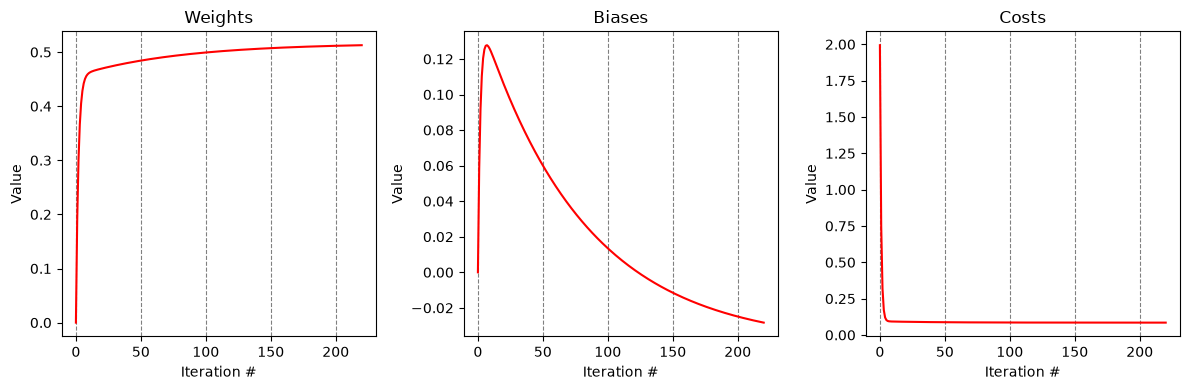

In [13]:
# A function to plot outputs from gradient descent
def plotOutputs(gdOutput):
    iterationsRan = len(gdOutput['costs'])
    toPlot = ['weights', 'biases', 'costs']
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    for i, key in enumerate(toPlot):
        axes[i].plot(range(iterationsRan), gdOutput[key], color='r')
        axes[i].set_xlabel('Iteration #')
        axes[i].set_ylabel('Value')
        axes[i].set_title(key.capitalize())
        axes[i].set_axisbelow(True)
        axes[i].xaxis.grid(color='gray', linestyle='dashed')
    fig.tight_layout()
    return fig

plotOutputs(output);

In [14]:
# Try the perceptron on data it has not seen before
testPredictions = ourPerceptron.predict(np.reshape(x[50:100], (-1, 1)))
testCost = mseCost(testPredictions, np.reshape(y[50:100], (-1, 1)))
'The mean squared error of our perceptron on the test half is: %f' % testCost

'The mean squared error of our perceptron on the test half is: 1.122684'

### 3.3 Benchmark against ordinary least squares

OLS solves the same problem in closed form. A gradient-descent perceptron that works should land on nearly the same line.

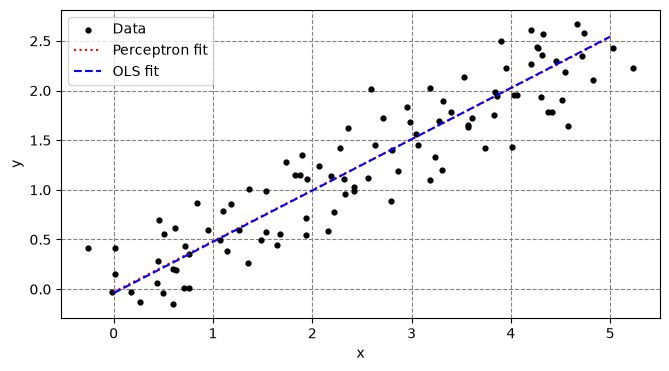

In [15]:
def compareOutputs(x, y, perceptron, xRange):
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.scatter(x, y, color='k', s=12)
    ax.set_aspect('equal')
    forLine = np.linspace(xRange[0], xRange[1])
    ax.plot(forLine, perceptron.predict(np.reshape(forLine, (-1, 1))),
            color='r', linestyle='dotted', linewidth=1.5)
    # How well do we do relative to OLS?
    OLSoutput = LinearRegression().fit(x[0:50].reshape(-1, 1), y[0:50])
    ax.plot(forLine, OLSoutput.predict(forLine.reshape(-1, 1)),
            color='b', linestyle='dashed', linewidth=1.5)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_axisbelow(True)
    ax.grid(color='gray', linestyle='dashed')
    ax.legend(['Data', 'Perceptron fit', 'OLS fit'])
    return fig

compareOutputs(x, y, ourPerceptron, xRange);

## 4. How the learning rate changes training

The learning rate $\eta$ controls the step size of gradient descent. Too small and training crawls; too large and the cost oscillates or diverges. The grid below trains the same perceptron from the same zero start with four learning rates and plots the cost curve for each (log scale on the cost axis).

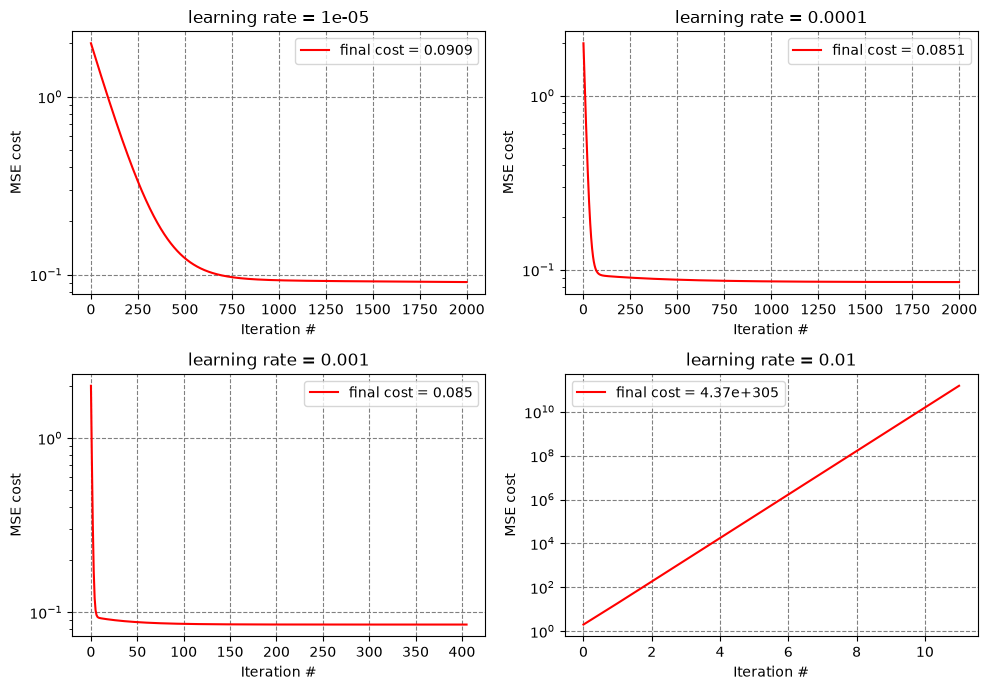

In [16]:
learningRates = [1e-5, 1e-4, 1e-3, 1e-2]

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
with np.errstate(over='ignore', invalid='ignore'):
    for ax, lr in zip(axes.ravel(), learningRates):
        gdPerceptron = simplePerceptron(w=[0], b_w=0, activation='none')
        gdOut = gradientDescent(gdPerceptron, mseCost, np.reshape(x[0:50], (-1, 1)),
                                y[0:50], lr, 2000, 1e-8)
        costs = np.array(gdOut['costs'])
        # Truncate the curve once the cost exceeds 1e12 (divergence)
        plotCosts = costs[costs < 1e12]
        ax.semilogy(plotCosts, color='r', label=f'final cost = {costs[-1]:.3g}')
        ax.set_xlabel('Iteration #')
        ax.set_ylabel('MSE cost')
        ax.set_title(f'learning rate = {lr:g}')
        ax.legend()
        ax.set_axisbelow(True)
        ax.grid(color='gray', linestyle='dashed')
fig.tight_layout()

Read the four panels: at $\eta = 10^{-5}$ the cost is still falling after 2000 iterations (too slow). At $\eta = 10^{-4}$ it converges but takes over a thousand iterations. At $\eta = 10^{-3}$ it converges in a few hundred iterations. At $\eta = 10^{-2}$ the cost grows without bound: the steps overshoot the minimum and training diverges (the curve stops where the cost becomes infinite).

### 4.1 Interactive explorer

The widget below lets you vary the learning rate, iteration count, stopping criterion, and initial weights, then retrain and replot. Widgets do not run in the static rendered book: **download and run this notebook in Jupyter to use it.** The static grid above shows the same lesson.

In [17]:
import ipywidgets as widgets
from IPython.display import display, clear_output
%matplotlib inline

In [18]:
# Create inputs
learningRateSlider = widgets.FloatLogSlider(
    value=.001,
    min=-6,
    max=1.0,
    step=1,
    description='Learning Rate:'
)

iterationsSlider = widgets.Dropdown(
    options=[1, 10, 100, 1000, 10000, 100000],
    value=100,
    description='Number of Iterations:'
)

stoppingCriterionSlider = widgets.FloatLogSlider(
    value=1e-4,
    min=-8,
    max=1,
    step=1,
    description='Stopping Criterion:'
)

startingWeight = widgets.BoundedFloatText(
    value=0,
    min=-50,
    max=50,
    description='Weight'
)

startingBias = widgets.BoundedFloatText(
    value=0,
    min=-50,
    max=5000,
    description='Bias'
)

# Create the "Update" button
updateBtn = widgets.Button(description="Update")

outputWidget = widgets.Output()

# Define the function to run when the "Update" button is clicked
def updateClick(_):
    with outputWidget:
        clear_output(wait=True)
        learningRate = learningRateSlider.value
        numIterations = iterationsSlider.value
        stoppingCriterion = stoppingCriterionSlider.value
        ourPerceptron.setWs([startingWeight.value], startingBias.value)
        output = gradientDescent(ourPerceptron, mseCost, np.reshape(x[0:50], (-1, 1)),
                                 y[0:50], learningRate, numIterations, stoppingCriterion)
        display(compareOutputs(x, y, ourPerceptron, xRange))
        display(plotOutputs(output))

# Set the function to be called when the button is clicked
updateBtn.on_click(updateClick)

# Display the widgets
display(learningRateSlider, iterationsSlider, stoppingCriterionSlider,
        startingWeight, startingBias, updateBtn, outputWidget)

FloatLogSlider(value=0.001, description='Learning Rate:', max=1.0, min=-6.0, step=1.0)

Dropdown(description='Number of Iterations:', index=2, options=(1, 10, 100, 1000, 10000, 100000), value=100)

FloatLogSlider(value=0.0001, description='Stopping Criterion:', max=1.0, min=-8.0, step=1.0)

BoundedFloatText(value=0.0, description='Weight', max=50.0, min=-50.0)

BoundedFloatText(value=0.0, description='Bias', max=5000.0, min=-50.0)

Button(description='Update', style=ButtonStyle())

Output()

## Summary

- A perceptron is a weighted sum plus a bias, passed through an activation function.
- The classic perceptron learning rule converges only on linearly separable data. It separated our event and noise windows using two detector features, and the two-feature choice let us draw the decision boundary.
- With no activation, the same perceptron is a linear regressor. Gradient descent on the MSE cost recovers nearly the same line as OLS.
- The learning rate sets the trade-off between slow convergence and divergence.

Next: [4.1 Neural Networks](mlgeo_4.1_NN.ipynb) stacks perceptrons into layers to handle data that a single line cannot separate.